> Task Sheet: In-Class Assignment 2  
> 2025/26 Critical 1: Mathematics and Statistics for Data Science


 - Student Name: Agata Sayfutdinova
 - Email:  a.sayfutdinova0220251@arts.ac.uk
  


# Exploring Spotify Most Streamed Songs 2023

In-Class Assignment 2 aims to demonstrate the practical aspects of knowledge on building statistical models of association for regression. It contributes to the following unit **learning outcomes**:
 - **LO 1:** Calculate and interpret summary statistics of datasets (Process)  
 - **LO 2:** Generate and interpret plots from data (Realisation)
 - **LO 3:** Calculate the probability of events occurring in a range of scenarios (Knowledge)

## Introduction

In this assignment, you will be exploring the 🎧 [Most Streamed Spotify Songs 2023](https://www.kaggle.com/datasets/nelgiriyewithana/top-spotify-songs-2023/data) dataset by Nidula Elgiriyewithana. The data is available in `.csv` format, in the "spotify-2023.csv" file next to this notebook.  

Your task is to use the dataset provided to work on the following three tasks. Put your answers, source code, and generated plots in this notebook and submit it.  

For each task, you need to:
1. Identify appropriate inferential statistical techniques and choose appropriate regression models that can be applied.
2. Discuss what the statistical result means and how they respond to the given question.
3. Generate plots/visualisations as applicable to illustrate your answers.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Read spotify-2023 data (CSV located alongside this notebook)
song_df = pd.read_csv('spotify-2023.csv', encoding='latin-1')

# Quick peek at the first 5 rows of data
song_df.head(5)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


## Tasks


-----------

##### **Task 1:** Artist analysis  

What are the top 25 artists with the highest total streams on spotify?  
Please choose one of these artist, and use statistics to describe their musical profile (e.g., What is the most common range of bpm? They prefers major mode or minor mode? Which year is the most active year of this artist? ...).

In [4]:
# Split the cells where one song is performed by multiple artists
# into seperate artist vlaues through the comma seperation 
song_df['artist(s)_name'] = song_df['artist(s)_name'].str.split(',')
# Create seperate rows of the seperated artists for each song
song_df = song_df.explode('artist(s)_name')
# Delete spaces from the artists name
song_df['artist(s)_name'] = song_df['artist(s)_name'].str.strip() 
#Get the top 25 artists by the number of streams
top_artists = song_df.groupby('artist(s)_name')['streams'].sum().sort_values(ascending=False).head(25)
top_artists


artist(s)_name
The Weeknd          23929760757
Bad Bunny           23813527270
Ed Sheeran          15316587718
Taylor Swift        14630378183
Harry Styles        11608645649
Eminem              10193727260
Dua Lipa             9980020481
Justin Bieber        8243081039
Drake                8043031261
BTS                  7780428159
Imagine Dragons      7719446948
Doja Cat             7712952203
Olivia Rodrigo       7442148916
Bruno Mars           7346351599
Coldplay             7091223298
Post Malone          6548593678
SZA                  6493011189
Arctic Monkeys       5569806731
Rauw Alejandro       5566283612
Kendrick Lamar       5555903581
Feid                 5438012982
Billie Eilish        4972152341
Lil Nas X            4803095082
The Chainsmokers     4795304992
Shawn Mendes         4741625382
Name: streams, dtype: int64

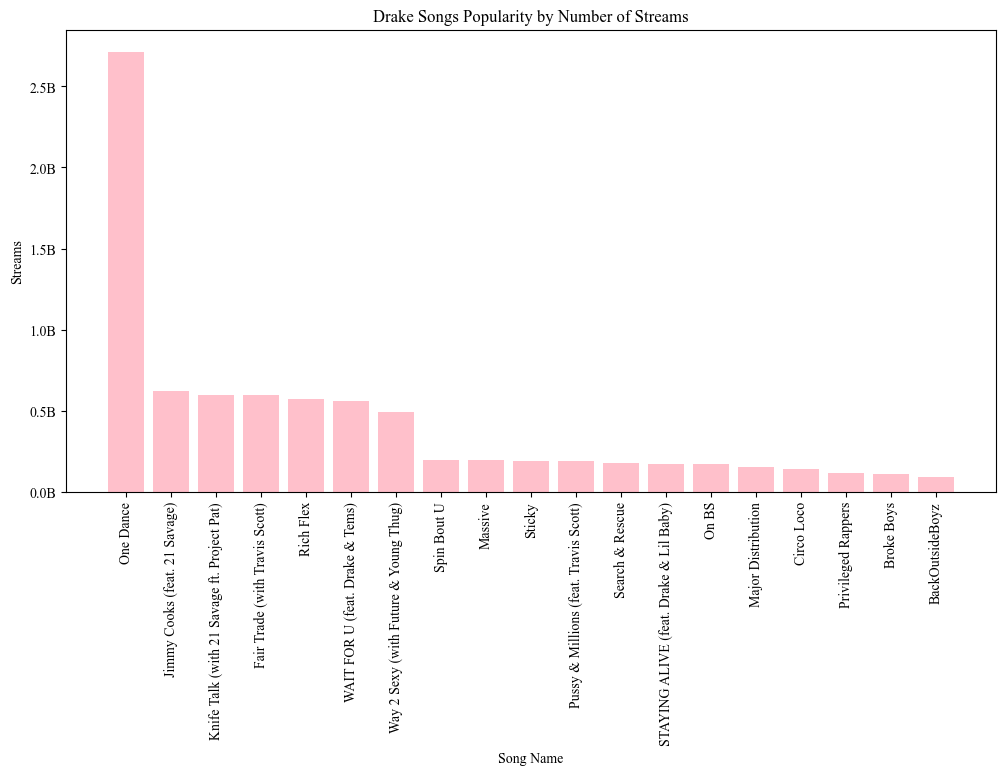

In [5]:
# I will be using Drake as the artist of my choice
import matplotlib.pyplot as plt
# Get all of Drake songs from the dataset
drake_songs = song_df[song_df['artist(s)_name'] == 'Drake']

# Find the most popular Drake song by the number of streams
# Sort all of the Drake songs by the number of streams in an descending value
drake_songs_sorted = drake_songs.sort_values('streams', ascending=False)

# Set the two axis of the grpah, y = number of streams of the songs, 
# x = the name of the song
songs_popularity = drake_songs_sorted['streams']
song_name = drake_songs_sorted['track_name']

# Plot the data on a bar chart
plt.figure(figsize=(12,6))
plt.rcParams['font.family'] = 'Times New Roman'
plt.bar(range(len(songs_popularity)), songs_popularity.values, color='pink')
plt.xticks(range(len(song_name)), song_name.values, rotation=90)
plt.xlabel('Song Name')
plt.ylabel('Streams')
plt.title("Drake Songs Popularity by Number of Streams")
ax = plt.gca()
# Set the format of streams in a 2 decimal places for readability
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))
plt.show()

#ChatLog reference 1

/var/folders/hv/60j97y6n3v549mc570rdssjw0000gn/T/ipykernel_87655/3214417799.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drake_songs['release_period'] = drake_songs['released_day'].apply(categorize_day)


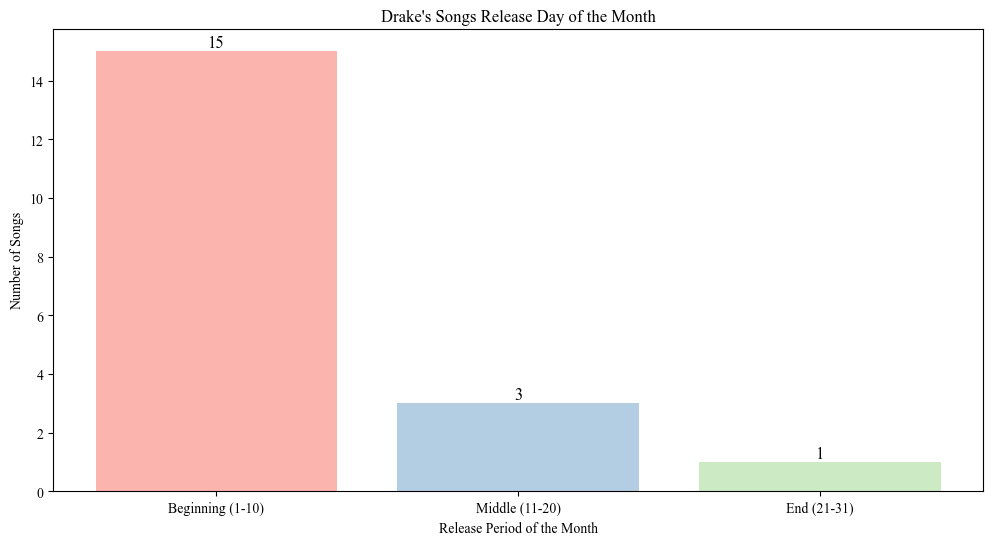

In [6]:

# Get the period of the month when Drake mostly released tracks
# Seperate the month into three periods, beginning, middle and end 
def categorize_day(day):
    if day <= 10:
        return 'Beginning (1-10)'
    elif day <= 20:
        return 'Middle (11-20)'
    else:
        return 'End (21-31)'


# Apply the created sorting method to the release day
drake_songs['release_period'] = drake_songs['released_day'].apply(categorize_day)

# Count songs in each category
release_period_counts = drake_songs['release_period'].value_counts()

# Plot the three cateogires onto a bar chart 
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = 'Times New Roman'
bars = plt.bar(release_period_counts.index, release_period_counts.values, color=plt.cm.Pastel1.colors)
plt.bar_label(bars, fontsize=12)
plt.xlabel('Release Period of the Month')
plt.ylabel('Number of Songs')
plt.title("Drake's Songs Release Day of the Month")
plt.show()

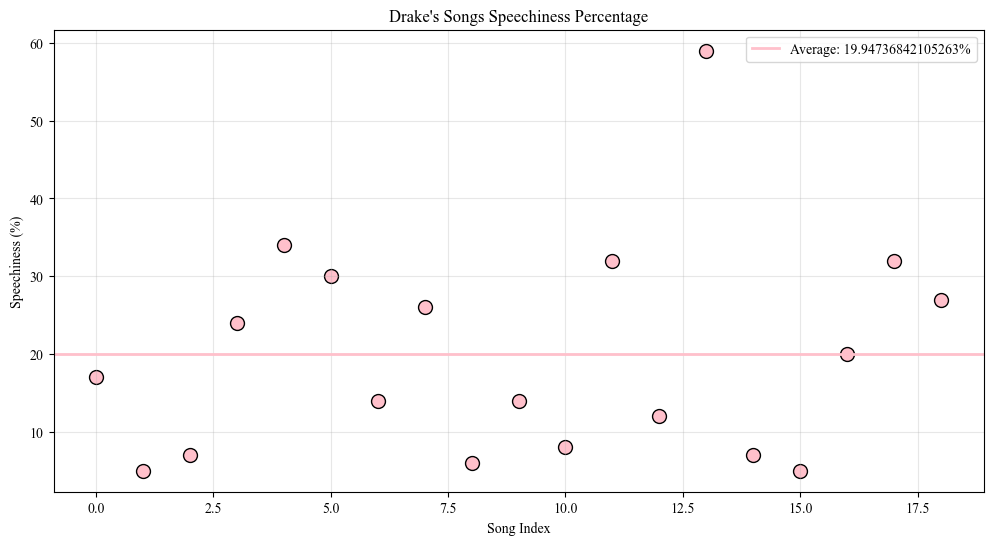

In [7]:
# Get information of the Drake songs speechiness values 
# Get the avarage value of speecheness of the artists songs
drake_songs_speechiness = drake_songs['speechiness_%']
average_speechiness = drake_songs_speechiness.mean()

# Create scatter plot with actual speechiness values, 
# including the avarage value on the the graph 
plt.figure(figsize=(12, 6))
plt.rcParams['font.family'] = 'Times New Roman'
plt.scatter(range(len(drake_songs_speechiness)), drake_songs_speechiness.values, color='pink', s=100, edgecolor='black')
plt.axhline(y=average_speechiness, color='pink', linestyle='-', linewidth=2, label=f'Average: {average_speechiness:}%')
plt.xlabel('Song Index')
plt.ylabel('Speechiness (%)')
plt.title("Drake's Songs Speechiness Percentage")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

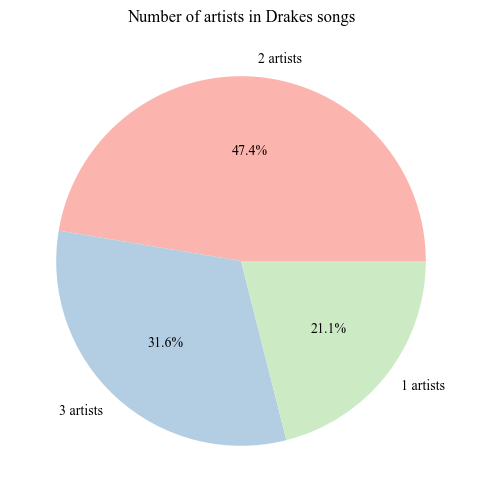

In [8]:
# Look at the ratio of number of artists in Drakes songs
# Get the values of the different values of artists(1,2,3)
number_of_artists = drake_songs['artist_count'].value_counts()

#Plot the figure on a pie chart
plt.figure(figsize=(6,6))
plt.rcParams['font.family'] = 'Times New Roman'
plt.pie(number_of_artists.values, labels = [f'{int(x)} artists' for x in number_of_artists.index], colors = plt.cm.Pastel1.colors, autopct='%1.1f%%')
plt.title("Number of artists in Drakes songs")
plt.show()

#ChatLog reference 2

**Answer:**  
I took a look at multiple aspects of Drakes performance. 
First, I explored what was the most popular song of the artist, and it turned out to be One Dance wiht over 2.5 Billion streams. Interesting, how of the top-3 songs with the highest streams by drake, two of them are a feat with other singers. However, his most popular single song is about 5 times more popular than the feat songs. We can also see that this dataset does not present all of the songs by the artist, only 19 tracks. This plays a big role in determining the most popular song, becuase this dataset does not include even half of his songs.
Then, i explored what was the period of the month when Drake released most of his tracks, and the result showed that most of his tracks were released in the begining of the month (1-10 days) at 15 out of the 19 tracks. This might be a dicision of the artist, or a coincidence, however, I do believe that this is a choice, not a random finding, becuase most of the artists release songs in the beginning of the month so that there is time for the platforms to collect the data about their songs, and when drawing conclusions, the streaming platform accumilates for the streams since release date till the end of the month.
After, I wanted to look at the percentage of speecheness in his songs. I plotted each track on a scatter plot with respect to the percentage of speecheness. The avarage value turned out to be at around 20%. This means that Drake's songs are in the lower spectrum of speechiness, which tells us that his sons are very melodic, and the genre is likely to be pop, which it is.
Finally, I looked at number of artists in each of Drakes songs. I plotted in on a bar chart with with three divisions of number of artists in each song ranging from 1-3. The most common value turned out to be 2 artists, which accumilates for 47% of the songs. This is a pretty high value, which means that half of the artists songs are performed feat someone. 



**GenAI Chat Log** [delete as applicable]

**What did I ask Copilot to do**:  
ChatLog reference 1:
I asked the copilot how to convert the values of the streams into another format decimal places
ChatLog reference 2: 
I asked the copilot how to create a pie chart with labels

**What did Copilot do**:  
ChatLog reference 1: Edited the code and added the line: ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e9:.1f}B'))
ChatLog reference 2: 
It created a pie chart wiht the labels in cell 7

**What did I decide to keep, change, discard?**
ChatLog reference 1: I used the generated line in my graph.
ChatLog reference 2: I used the code generated for creating the pie chart, changes the colors, labels, font size and figsize.


-----------

##### **Task 2:** Audio Features
Here we'll look at the seven audio features: `danceability_%`, `valence_%`, `energy_%`, `acousticness_%`, `instrumentalness_%`, `liveness_%`, `speechiness_%`.  
 - Could you visualise the relationships between variable pairs, using a correlation heatmap? 
 - Which pair of features has the highest positive correlation? 
 - Which pair has the highest negative correlation?

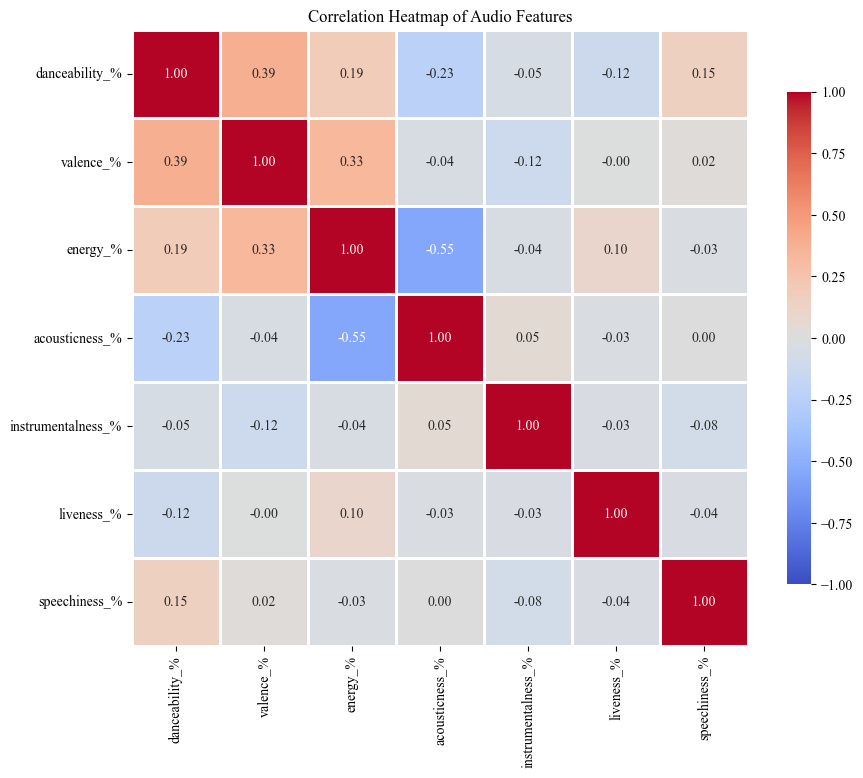

In [9]:
# Put your code here
import seaborn as sns
import numpy as np

# Select the seven audio features
audio_features = ['danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 
                  'instrumentalness_%', 'liveness_%', 'speechiness_%']

# Calculate correlation
# matrix of the features listed in audio_features
correlation_matrix = song_df[audio_features].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
plt.rcParams['font.family'] = 'Times New Roman'
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, 
            fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Audio Features')

plt.show()


In [10]:
# Put your code here or add more code cells as needed
# First I created an empty array for the pairs of correclation values
corr_pairs = []
# Then I used a loop that goes through correlation matrix and gets the
# value of correlation betweet the two variables. I recorded the names of 
# the features and the value of the correlation
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'feature1': correlation_matrix.columns[i],
            'feature2': correlation_matrix.columns[j],
            'correlation': correlation_matrix.iloc[i, j]
        })

# Sort the array so that the correlations in the array are in 
# an ascending order from the smallest to largest 
corr_pairs_sorted = sorted(corr_pairs, key=lambda x: x['correlation'])

# Got the last variable from the array which stands for the 
# highest correlation after sorting
# and get its value and the names of the correlating features
print("Highest positive correlation:")
print(f"{corr_pairs_sorted[-1]['feature1']} and {corr_pairs_sorted[-1]['feature2']}: {corr_pairs_sorted[-1]['correlation']:.3f}")

# Get the first variable from the array which stands for the highest negative
# corelation between features
# and get its value and the names of the correlating features
print("\nHighest negative correlation:")
print(f"{corr_pairs_sorted[0]['feature1']} and {corr_pairs_sorted[0]['feature2']}: {corr_pairs_sorted[0]['correlation']:.3f}")

Highest positive correlation:
danceability_% and valence_%: 0.387

Highest negative correlation:
energy_% and acousticness_%: -0.548


**Answer:**  
The highest correlation in this pair is the correlation betweeen dancability and valence at 0.387 , meanwhile the most negative relationship stands between energy and acousticness at the value of -0.548. This is a very logical correlation, becuase songs with high danceability are always positive and happy, which explains the correlation with the high values of valence, where high values mean a happy, positive song, and low value describes sad tone of the song. Same logic is found in the inverse relationship between energy and acousticness. Higher energy values means that the songs are loud and fast. Meanwhile the higher acousticness values mean that the song uses real instruments and minimal electronic production, meanwhile the lower values indicate that the music is electronic, synthesized. And, logicaly speaking, a faster and lounder song is usually made with usign a lot of electronic and synthesized motives, which is proven by their negative correlation.


**GenAI Chat Log** [delete as applicable]

**What did I ask Copilot to do**:  
I asked the copilot how to calculate the correlation of two features.
I asked how to get all the corresponding values from the array at the last and the first index

**What did Copilot do**:  
Copilot suggested the use of the .corr() 
Copilot generated the code lines: 
print(f"{corr_pairs_sorted[-1]['feature1']} and {corr_pairs_sorted[-1]['feature2']}: {corr_pairs_sorted[-1]['correlation']:.3f}")
print(f"{corr_pairs_sorted[0]['feature1']} and {corr_pairs_sorted[0]['feature2']}: {corr_pairs_sorted[0]['correlation']:.3f}")

**What did I decide to keep, change, discard?**
I implemented the use of the .corr() function and used the lines generated for the retraction of the values at the corresponding indexes. 


-----------

##### **Task 3:** Predicting stream-per-month of a song

We want to create a regression model to predict the number of stream of a new song. However, the current `streams` column in the dataset denotes the number of stream of a song of all time (i.e., songs that are released for a longer time have a time advantage in hitting higher number of streams). Therefore, the first step is to add a new column called **"streams-per-month"** based on the months since the song's release. The code for this is provided below:

In [11]:
# calculate streams-per-month for each track
song_df = song_df.dropna(subset=['streams'])
song_df['months-since-release'] = ((2023 - song_df['released_year']) * 12) + (12 - song_df['released_month']) 
song_df['streams'] = song_df['streams'].astype('int')
song_df['streams-per-month'] = song_df['streams'] / song_df['months-since-release']
song_df['streams-per-month'] = song_df['streams-per-month'].astype('int')
song_df.head(5)

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,months-since-release,streams-per-month
0,Seven (feat. Latto) (Explicit Ver.),Latto,2,2023,7,14,553,147,141381703,43,...,Major,80,89,83,31,0,8,4,5,28276340
0,Seven (feat. Latto) (Explicit Ver.),Jung Kook,2,2023,7,14,553,147,141381703,43,...,Major,80,89,83,31,0,8,4,5,28276340
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,Major,71,61,74,7,0,10,4,9,14857365
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,Major,51,32,53,17,0,31,6,6,23333995
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,Major,55,58,72,11,0,11,15,52,15400784


Now we're ready to work on the regression task: please inspect all the columns in the dataset, and create a regression model that predict the streams-per-month of a new song. You can experiment and choose different regression models (e.g., linear/polynomial regression, single-variable/multi-variable regression...)

In [55]:
# Put your code here

from scipy import stats

# Define the y variable to be the streams-per-month
y = song_df['streams-per-month']

# Get column names from 'artist_count' to 'in_apple_playlists' from the dataset
columns = song_df.columns.tolist()
start_idx = columns.index('artist_count')
end_idx = columns.index('speechiness_%')

# Get the range of columns for testing, from the first to last
columns_to_test = columns[start_idx:end_idx+1]

# Create an array to store the results
correlation_results = []

# Loop through each column and calculate Pearson's r
for col in columns_to_test:
    # Skip the columns with non-numerical values 
    try:
        #assign the x-value to be the current column
        x = song_df[col]
        # run a pearsons test on the curent column vs streams per month
        r, p = stats.pearsonr(x, y)
        # insert the results into the array, using the name of the current 
        # column and the calculated r-coefficient 
        correlation_results.append({
            'column': col,
            'r_coefficient': r,
        })
    except:
        continue

# Frint the results in a dataframe format
results = pd.DataFrame(correlation_results)
results = results.sort_values('r_coefficient', ascending=False)
print(results)


                  column  r_coefficient
9       in_deezer_charts       0.588414
6                streams       0.493901
5      in_spotify_charts       0.469364
7     in_apple_playlists       0.461675
8        in_apple_charts       0.430796
1          released_year       0.241497
4   in_spotify_playlists       0.168192
3           released_day       0.093815
2         released_month       0.069305
11        danceability_%       0.061111
10                   bpm       0.032824
13              energy_%       0.017794
12             valence_%      -0.003078
16            liveness_%      -0.029466
14        acousticness_%      -0.040433
17         speechiness_%      -0.050858
0           artist_count      -0.054600
15    instrumentalness_%      -0.069758


After looking at the persons r coefficient to locate the variable which has the highest correlation with the streams-per-month, I will be using the in_deezer_charts column to build a simple regression model for predicting streams per month. 

In [ ]:
from sklearn.linear_model import LinearRegression

# First I build a regression model using the variable "In_deezer_charts"

# Assigned the two variables for the model to evaluate
X1 = song_df[['in_deezer_charts']]
y = song_df['streams-per-month']

# created model1 which calculates a linear regression
model1 = LinearRegression()
# input the defined varibales into the model to calculate
model1.fit(X1, y)

# calculate the r coeficient of the model
r2_model1 = model1.score(X1, y)


To see whether there is a better way to predict streams per month, I will be using the aspects in the dataframe above with the highest r-coefficient. However, I will skip the streams column becuase it directly reffers to the streams per month aspect. I will be building a multiple regression model to combine all of the top 4 aspects with the highest r-coefficient.

In [52]:
# assigned the x variables to represent the top 4 values of the dataframe
X2 = song_df[['in_deezer_charts',
         'in_apple_charts',
         'in_spotify_charts',
         'in_apple_playlists']]

# create a linear regression model 
model2 = LinearRegression()
# load the multiple varibales into the model
model2.fit(X2, y)

# calculate the r coefficient of the model
r2_model2 = model2.score(X2, y)

In [53]:
print("Model1 r^2:", r2_model1)
print("Model2 r^2:", r2_model2)

Model1 r^2: 0.3462308606970895
Model2 r^2: 0.4416680020861019


After comparing the results of the two models, we can observe that the first model shows around 34% accuracy of predicting the streams per month by the in_deezer_charts aspect. When we include more aspects about the song to build a mulitple regression, the percentage increases to around 44% of dependance of the streams-per-month. These results indicate that muliple aspects can desribe the trend of streams per month better than only one aspect can. Even through we see an increase in correlation between streams and aspects of the songs, a high percentage of the dependancy is still unexplained, which means that there are other aspects beyond the ones introduced in the dataset that can explain the performance of a song, an example would be the marketing of the release or popularity of the artist.

Firther I decided to display the two models on a graph for visual representation of their accuracy.

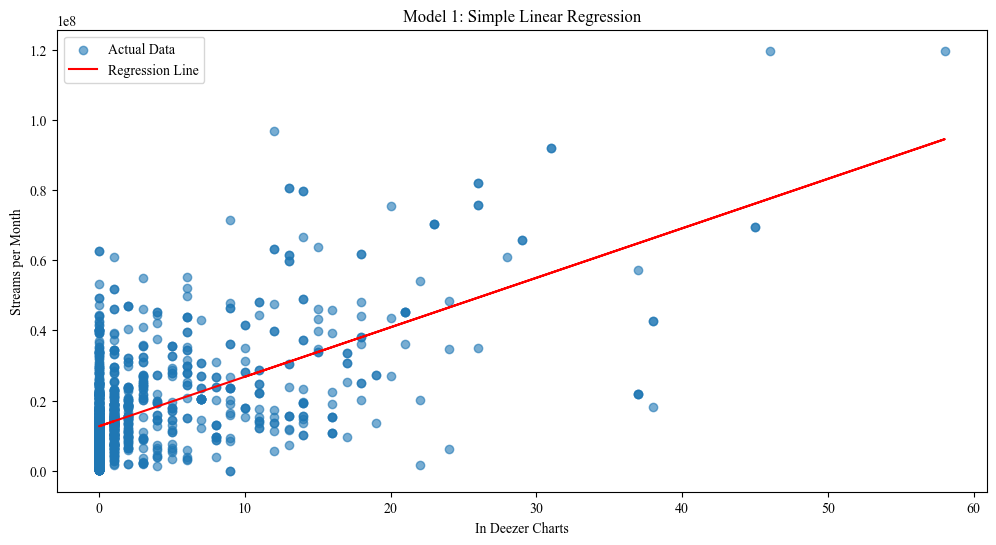

In [46]:
x = song_df['in_deezer_charts']
y = song_df['streams-per-month']

y_pred1 = model1.predict(X1)

plt.figure(figsize=(12,6))
plt.scatter(x, y, alpha=0.6, label='Actual Data')
plt.plot(x, y_pred1, color='red', label='Regression Line')
plt.xlabel('In Deezer Charts')
plt.ylabel('Streams per Month')
plt.title('Model 1: Simple Linear Regression')
plt.legend()
plt.show()

On this graph we can see a positive correlation between the deezer chart presence and streams per month. Although there is a relationship between the variables, we can see that the spreaad of the points from the regression line on the graph indicates that this aspect doesnt accurately and independintly describe the performance of the song.

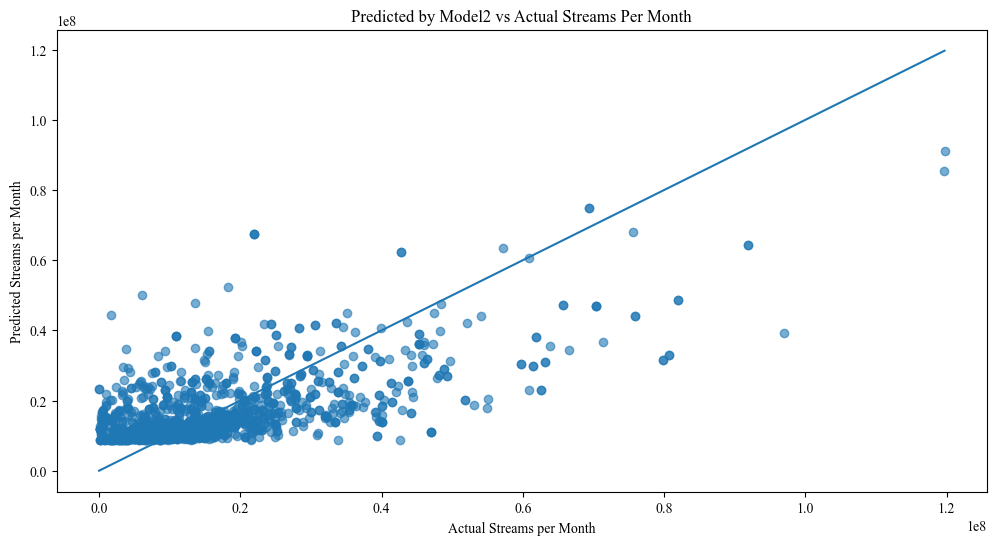

In [54]:
y_pred2 = model2.predict(X2)

plt.figure(figsize=(12,6))
plt.scatter(y, y_pred2, alpha=0.6)
plt.plot([y.min(), y.max()],
         [y.min(), y.max()])

plt.xlabel('Actual Streams per Month')
plt.ylabel('Predicted Streams per Month')
plt.title('Predicted by Model2 vs Actual Streams Per Month')
plt.show()

The grpah above shows that the mulitple regression model performs reasonably good, wiht the clustered values on the lower-streams songs, however there is a weakness in the perdictions for the high-stream songs.

**Answer:**  
The analysis shows that in order to predict streams per month of a song, we would require a multiple regression model, rather than using one aspect of the song, like "in_deezer_charts" used in my example. Even though a miltiple regression model performs well at around 44% accuracy, it still doesnt fully explain the predicted streams of a song. We might suggest that other aspects outside the dataset should also be explored to more accurately predict the streams. 

**GenAI Chat Log**

**What did I ask Copilot to do**:  
I asked the copilot how I can create a regression model
I asked how to skip the values if they are non-numerical
**What did Copilot do**:  
The copilot suggested the use of LinearRegression function from the sklearn library, and provided me with instructions on how to use it.
The copilot suggested the use fo try, except function, and suggested to print a warning error message when the value is non-numerical 
**What did I decide to keep, change, discard?**
I used the suggestion library and the mehtods to create the linear models.
I used the try, except function but decided to jsut skip the column with the non-numerical values. 

-----------

## Generative AI Disclosure  

The code this notebook was created with assistance from Copilot (GPT5 mini). The content has been reviewed and edited by Agata Sayfutdinova. For more information on the extent and nature of AI usage, please refer to the in-code AI disclosure and chat logs
